<a href="https://colab.research.google.com/github/jenyabydaev-web/homeworkk/blob/homework/Task2%202555051%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

4. 네이버와 구글의 서버 헤더 정보 비교하기


In [2]:
import requests

def compare_headers(url):
    response = requests.get(url)
    print(f"--- [{url}] Headers ---")
    for key, value in response.headers.items():
        print(f"{key}: {value}")
    print("\n")

# 네이버와 구글 비교 실행
compare_headers("https://www.naver.com")
compare_headers("https://www.google.com")

--- [https://www.naver.com] Headers ---
Content-Type: text/html; charset=UTF-8
Cache-Control: no-cache, no-store, must-revalidate
Pragma: no-cache
x-frame-options: DENY
x-xss-protection: 1; mode=block
strict-transport-security: max-age=63072000; includeSubdomains
referrer-policy: unsafe-url
Content-Encoding: gzip
Server: nfront
Date: Thu, 02 Apr 2026 12:53:37 GMT
Transfer-Encoding: chunked
Connection: keep-alive, Transfer-Encoding
Vary: Accept-Encoding


--- [https://www.google.com] Headers ---
Date: Thu, 02 Apr 2026 12:53:37 GMT
Expires: -1
Cache-Control: private, max-age=0
Content-Type: text/html; charset=ISO-8859-1
Content-Security-Policy-Report-Only: object-src 'none';base-uri 'self';script-src 'nonce-jPek9D3dxuyYRzzli4W6Ig' 'strict-dynamic' 'report-sample' 'unsafe-eval' 'unsafe-inline' https: http:;report-uri https://csp.withgoogle.com/csp/gws/other-hp
Accept-CH: Sec-CH-Prefers-Color-Scheme
P3P: CP="This is not a P3P policy! See g.co/p3phelp for more info."
Content-Encoding: gzip


5. url = "https://jsonplaceholder.typicode.com/users" 에서 requests 모듈로 json파일로
불러와 데이터프레임으로 저장하고 컬럼명(변수명)이 “address”인 series의 내용을
데이터프레임으로 변경하라


In [3]:
import requests
import pandas as pd

# 1. API를 통해 데이터 가져오기
# requests 모듈을 사용하여 지정된 URL에서 JSON 데이터를 호출합니다.
url = "https://jsonplaceholder.typicode.com/users"
response = requests.get(url)
data = response.json()

# 2. 데이터를 데이터프레임으로 저장하기
# 불러온 JSON 데이터를 pandas DataFrame 형식으로 변환합니다.
df = pd.DataFrame(data)

# 3. "address" 컬럼의 내용을 새로운 데이터프레임으로 변환하기
# 'address' 열은 딕셔너리 형태의 데이터를 포함하고 있으므로,
# pd.json_normalize를 사용하여 이를 별도의 컬럼들(street, suite 등)로 확장합니다.
address_df = pd.json_normalize(df['address'])

# 결과 확인 (상위 5개 행 출력)
print(address_df.head())

              street      suite           city     zipcode   geo.lat  \
0        Kulas Light   Apt. 556    Gwenborough  92998-3874  -37.3159   
1      Victor Plains  Suite 879    Wisokyburgh  90566-7771  -43.9509   
2  Douglas Extension  Suite 847  McKenziehaven  59590-4157  -68.6102   
3        Hoeger Mall   Apt. 692    South Elvis  53919-4257   29.4572   
4       Skiles Walks  Suite 351     Roscoeview       33263  -31.8129   

     geo.lng  
0    81.1496  
1   -34.4618  
2   -47.0653  
3  -164.2990  
4    62.5342  


6. url = "https://jsonplaceholder.typicode.com/posts" 에서 데이터를 불러와 index가
짝수인 내용만 엑셀로 저장하여 다운로드 받아라

In [4]:
import requests
import pandas as pd

# 1. 데이터 불러오기
# requests를 사용하여 JSON 데이터를 가져옵니다.
url = "https://jsonplaceholder.typicode.com/posts"
response = requests.get(url)
df = pd.DataFrame(response.json())

# 2. 인덱스가 짝수인 행만 필터링하기
# index % 2 == 0 조건을 사용하여 짝수 번째 인덱스 데이터만 선택합니다.
even_df = df[df.index % 2 == 0]

# 3. 엑셀 파일로 저장 및 다운로드
# 필터링된 데이터를 'posts_even.xlsx'라는 이름으로 저장합니다.
file_name = "posts_even.xlsx"
even_df.to_excel(file_name, index=False)

print(f"{file_name} 파일이 생성되었습니다.")

posts_even.xlsx 파일이 생성되었습니다.


7. url = "https://jsonplaceholder.typicode.com/posts"에서 데이터를 불러와
requests.get(url, params=params)를 사용하여 사용자가 Gradio UI를 통해 userId를
입력하면 실시간으로 해당 데이터를 필터링하여 Pandas 데이터프레임으로 보여주는
코드를 작성하라

In [1]:
import requests
import pandas as pd
import gradio as gr

def get_user_posts(user_id):
    # 1. API URL 설정
    url = "https://jsonplaceholder.typicode.com/posts"

    # 2. params를 사용하여 특정 userId 데이터 필터링
    params = {'userId': user_id}

    try:
        response = requests.get(url, params=params)

        # 상태 코드 확인 (200: 성공)
        if response.status_code == 200:
            data = response.json()

            # 3. 데이터를 Pandas 데이터프레임으로 변환
            df = pd.DataFrame(data)

            # 결과 요약 메시지 구성
            status_msg = f"성공적으로 {len(df)}개의 데이터를 불러왔습니다. (상태 코드: {response.status_code})"
            return status_msg, df
        else:
            return f"데이터를 가져오는데 실패했습니다. (상태 코드: {response.status_code})", pd.DataFrame()

    except Exception as e:
        return f"오류 발생: {str(e)}", pd.DataFrame()

# 4. Gradio UI 구성 (이미지 예시와 동일한 레이아웃)
with gr.Blocks() as demo:
    gr.Markdown("## 🌐 네트워크 & 웹 데이터 수집 실습")
    gr.Markdown("userId를 입력하여 REST API로부터 특정 사용자의 데이터를 Pandas 데이터프레임으로 가져옵니다.")

    with gr.Row():
        user_input = gr.Number(label="조회할 userId 입력 (1~10)", precision=0)
        submit_btn = gr.Button("데이터 가져오기", variant="primary")

    status_output = gr.Textbox(label="네트워크 상태 및 결과 요약")
    df_output = gr.DataFrame(label="수집된 데이터 (Pandas DataFrame)")

    # 버튼 클릭 이벤트 연결
    submit_btn.click(
        fn=get_user_posts,
        inputs=user_input,
        outputs=[status_output, df_output]
    )

# 인터페이스 실행
if __name__ == "__main__":
    demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://74bedc70a4a7ec79f6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


8. https://data.seoul.go.kr/dataList/OA-15246/F/1/datasetView.do# 3개월
데이터(서울특별시 공공자전거 이용정보(일별)_2510.csv, 서울특별시 공공자전거
이용정보(일별)_2511.csv, 서울특별시 공공자전거 이용정보(일별)_2512.csv)를 다운받아
merge하여 기본 통계분석 사이트를 gradio UI로 만들어라(여러 가지 화면으로) —> 과제
제출 (4월3일에 무작위로 3명 데모 예정)


데이터 로드 완료! 컬럼명: ['대여일자', '대여소번호', '대여소', '대여구분코드', '성별', '연령대', '이용건수', '운동량', '탄소량', '이동거리(M)', '이용시간(분)']


/tmp/ipykernel_18971/3369788142.py:53: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18971/3369788142.py:53: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18971/3369788142.py:53: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18971/3369788142.py:53: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18971/3369788142.py:53: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18971/3369788142.py:53: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18971/3369788142.py:53: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.ti

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://53286600faad8d9c4b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missi

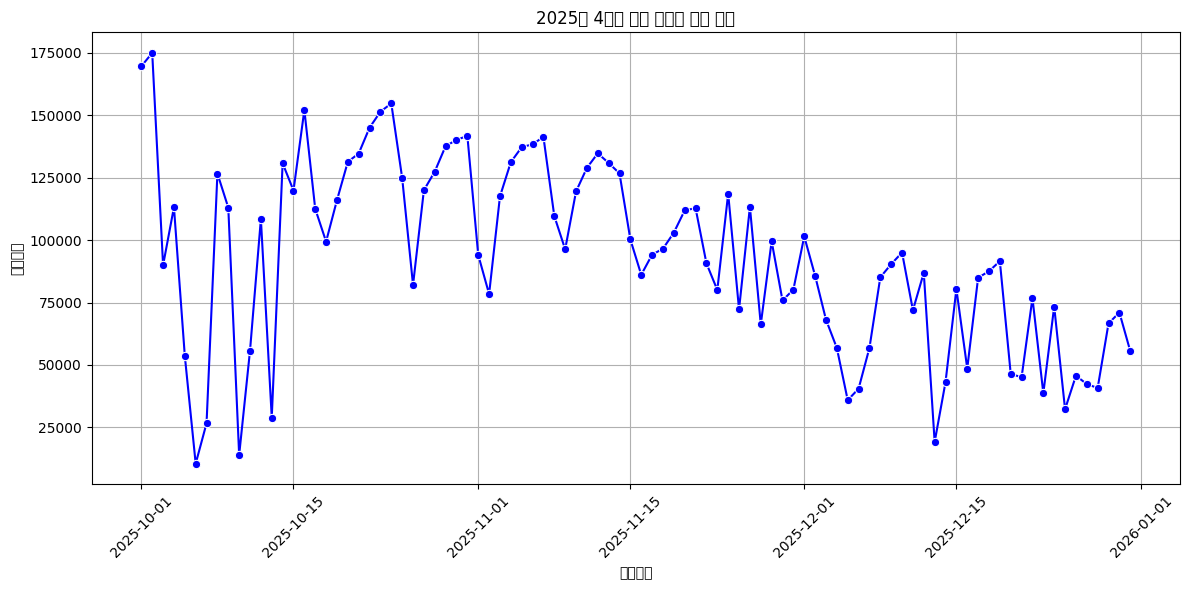

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


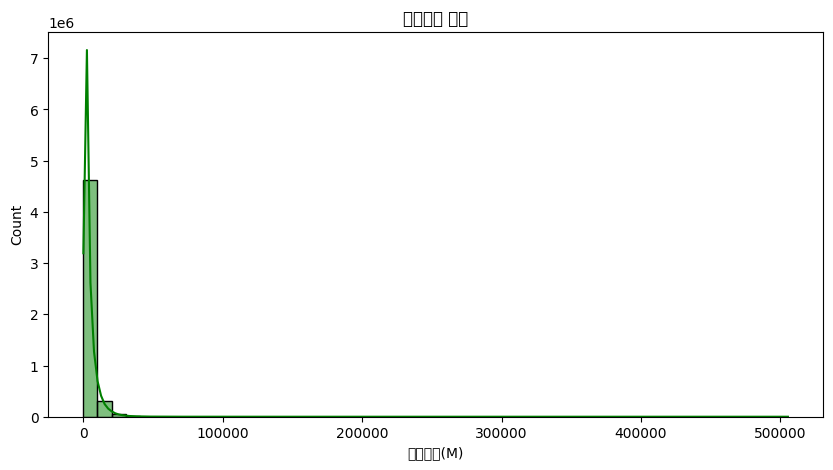

In [6]:
import pandas as pd
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 1. 한글 폰트 설정 (Colab 환경 기준)
# 폰트 설치 후 실행한다고 가정합니다.
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드 및 전처리 함수
def load_data():
    files = ['서울특별시 공공자전거 이용정보(일별)_2510.csv',
             '서울특별시 공공자전거 이용정보(일별)_2511.csv',
             '서울특별시 공공자전거 이용정보(일별)_2512.csv']

    df_list = []
    for f in files:
        # cp949 인코딩으로 읽기
        temp_df = pd.read_csv(f, encoding='cp949')
        # 컬럼명의 앞뒤 공백 제거 (매우 중요!)
        temp_df.columns = temp_df.columns.str.strip()
        df_list.append(temp_df)

    combined_df = pd.concat(df_list, ignore_index=True)

    # '대여일자'를 날짜 형식으로 변환 (정렬 및 그래프를 위해)
    combined_df['대여일자'] = pd.to_datetime(combined_df['대여일자'])
    return combined_df

# 데이터 로드
try:
    df = load_data()
    print("데이터 로드 완료! 컬럼명:", df.columns.tolist())
except Exception as e:
    print(f"데이터 로드 중 오류 발생: {e}")

# 3. 분석 함수들
def get_basic_stats():
    # 기본 통계 정보 추출
    return df.describe()

def plot_usage_by_day():
    # 일별 이용건수 시각화
    plt.figure(figsize=(12, 6))
    # '이용건수' 컬럼의 공백을 제거했으므로 바로 사용 가능
    df_daily = df.groupby('대여일자')['이용건수'].sum().reset_index()
    sns.lineplot(data=df_daily, x='대여일자', y='이용건수', marker='o', color='blue')
    plt.title('2025년 4분기 일별 따릉이 이용 추이')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    return plt.gcf()

def plot_dist():
    # 이용거리 분포 시각화 (추가 화면용)
    plt.figure(figsize=(10, 5))
    sns.histplot(df['이동거리(M)'], bins=50, kde=True, color='green') # Corrected column name
    plt.title('이동거리 분포')
    return plt.gcf()

# 4. Gradio UI 구성
with gr.Blocks() as demo:
    gr.Markdown("# 🚲 서울특별시 공공자전거 이용 분석 대시보드")
    gr.Markdown("2025년 10월 ~ 12월 데이터를 기반으로 한 통계 분석 사이트입니다.")

    with gr.Tab("📊 데이터 요약"):
        gr.Markdown("### 수치형 데이터 기본 통계분석")
        gr.DataFrame(get_basic_stats())

    with gr.Tab("📈 이용 추이"):
        gr.Markdown("### 일별 따릉이 이용건수 변화")
        gr.Plot(plot_usage_by_day())

    with gr.Tab("📏 분포 분석"):
        gr.Markdown("### 이용거리 분포 확인")
        gr.Plot(plot_dist())

    with gr.Tab("📋 데이터 미리보기"):
        gr.Markdown("### 전체 결합 데이터 (상위 100행)")
        gr.DataFrame(df.head(100))

# 데모 실행
if __name__ == "__main__":
    demo.launch()

9.Gemini API Key 발급 및 코딩하기(Agent AI)
a. 7번과제를 번역하여 제공해주는 UI를 만들어라 (아래는 API 키 없이 사용)
i. 처음 1행만 번역하여 제공
from google.colab import ai
response = ai.generate_text("What is the capital of
France?")

In [9]:
# 1. 라이브러리 불러오기
# 구글 코랩에서 별도의 API 키 없이 AI를 사용하기 위한 모듈입니다.
from google.colab import ai
import pandas as pd

# 2. 데이터 준비 (7번 과제 데이터 활용)
# 과제 7번에서 생성한 데이터프레임(df)이 있다고 가정합니다.
# 여기서는 예시를 위해 샘플 데이터를 만듭니다.
# df = pd.DataFrame(response.json()) # 실제 과제에서는 이 방식을 사용했을 것입니다.
sample_data = {'title': ["First post title from task 7", "Second post title"]}
df = pd.DataFrame(sample_data)

# 3. 첫 번째 행 추출 및 번역 요청
# iloc[0]을 사용하여 첫 번째 행의 데이터를 가져옵니다.
target_text = df.iloc[0]['title']

# AI에게 줄 명령어(프롬프트)를 작성합니다.
prompt = f"다음 문장을 한국어로 번역해줘: '{target_text}'"

# 4. Gemini AI를 통한 번역 실행
# ai.generate_text 함수를 호출하여 번역 결과를 생성합니다.
response = ai.generate_text(prompt)

# 5. 결과 확인
# 번역된 텍스트를 출력합니다.
print("--- 번역 결과 ---")
print(f"원문: {target_text}")
print(f"번역: {response}")

--- 번역 결과 ---
원문: First post title from task 7
번역: "7번 과제의 첫 번째 게시물 제목"


10. https://huggingface.co/ 를 클릭하여 멀티모달 LLM을 사용해 보자
a. Hugging Face(허깅페이스)는 AI계의 깃허브(GitHub)
b. 전 세계 개발자와 연구자들이 자신이 만든 AI 모델, 데이터셋, 데모 웹사이트를
공유하고 협업하는 거대한 생태계

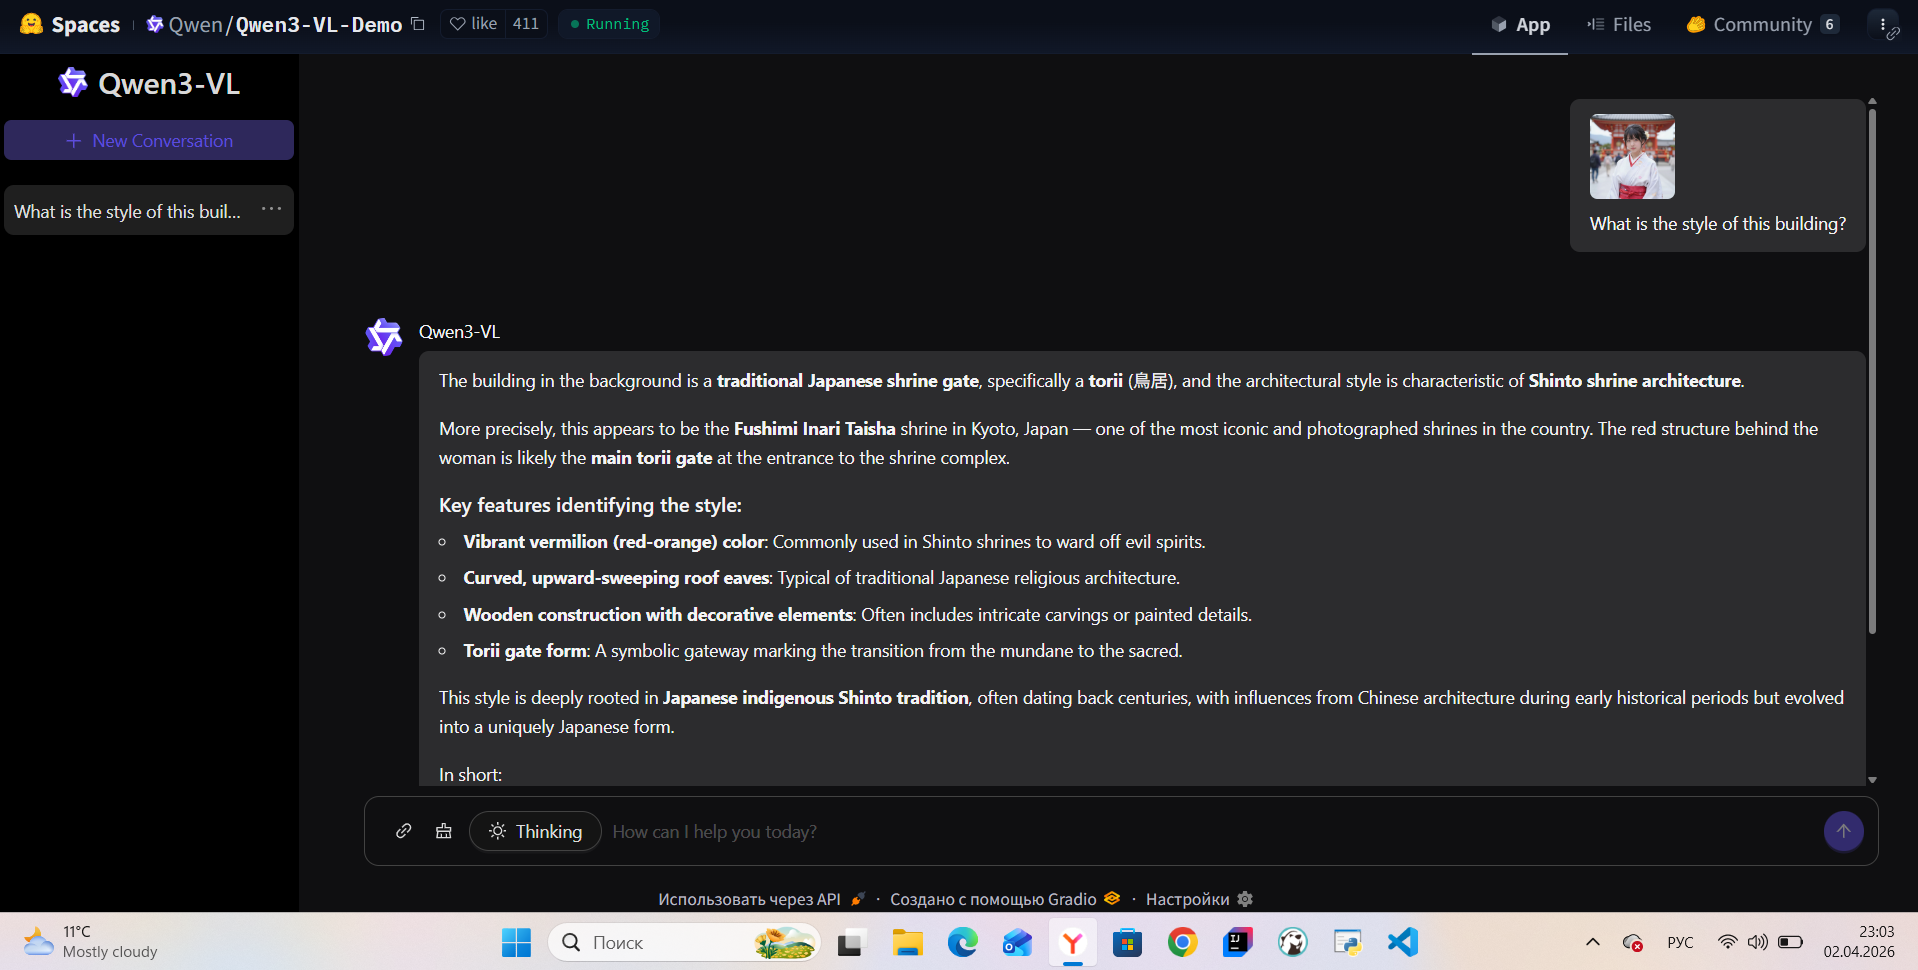

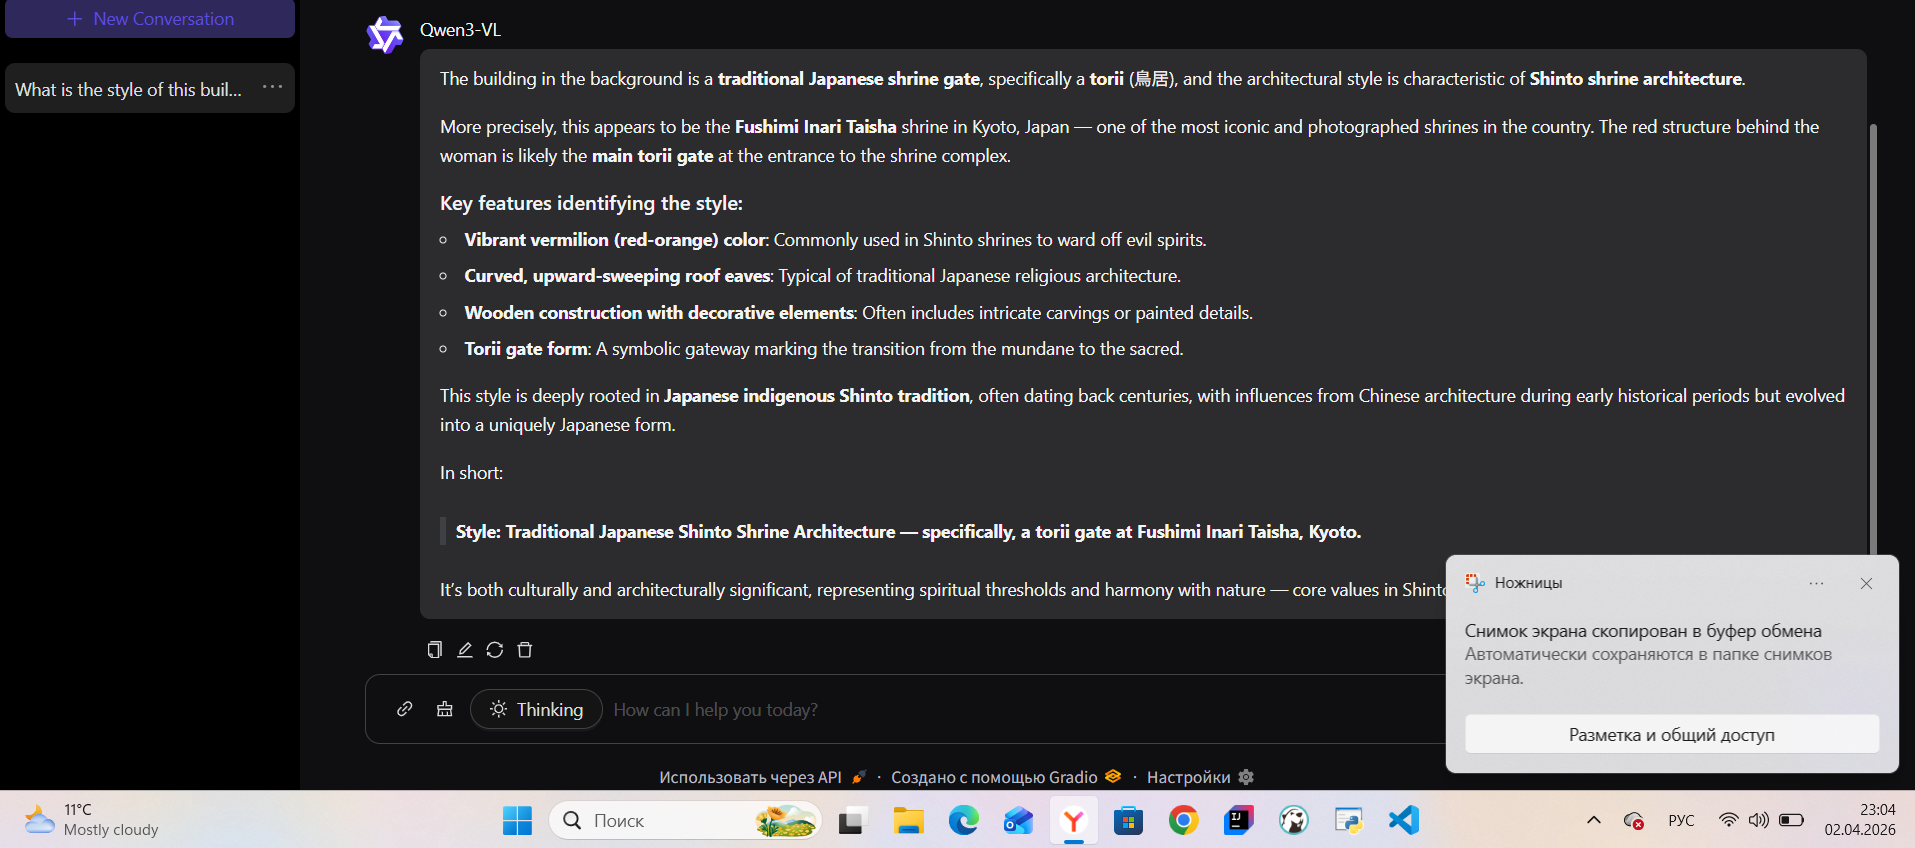

"Hugging Face의 'Z-Image-Turbo' 모델을 사용하여 'generate a photo of japan girl'이라는 프롬프트로 이미지를 신속하게 생성해 보았습니다. 이는 Hugging Face에서 제공하는 Text-to-Image 기술의 좋은 예시입니다."

11. https://www.youtube.com/watch?v=JvdBJZ-qR18 (Your open-source companion -
Reachy Mini)

это путь от обработки простых данных до управления сложным ИИ и роботами через современные облачные платформы.